# Phase 2 — Unimodal Baselines
## Multi-Modal Fusion for Breast Cancer Subtype Classification
**Task:** 3-class subtype classification — HR+ · HER2+ · TNBC  
**Evaluation:** 5-fold stratified CV · Accuracy · Macro F1 · Macro AUC (OvR)  
**Goal:** Each modality in isolation — fusion in Phase 3 must beat every baseline here

## Setup & Task Definition

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'open-clip-torch', 'pytorch-tabnet', 'xgboost', 'scikit-learn',
    'torch', 'torchvision', 'tqdm', 'python-dotenv', 'transformers',
    'accelerate'], capture_output=True)

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from dotenv import load_dotenv
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA

load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))
HF_TOKEN = os.getenv('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN or ''

ROOT    = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(ROOT, 'data')
IMG_DIR  = os.path.join(DATA_DIR, 'MRI_and_SVS_Patches', 'MRI_and_SVS_Patches')
EMB_DIR  = os.path.join(DATA_DIR, 'embeddings')
FIG_DIR  = os.path.join(ROOT, 'figures')
os.makedirs(EMB_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print(f'Device: {DEVICE} | HF: {"OK" if HF_TOKEN else "MISSING"}')

Device: cpu | HF: OK


In [2]:
# Recreate aligned cohort + subtype labels (same pipeline as Phase 1)
clin_demo  = pd.read_csv(os.path.join(DATA_DIR, 'Clinical_Demographic_Data.csv'))
clin_treat = pd.read_csv(os.path.join(DATA_DIR, 'Clinical_Treatment_Data.csv'), low_memory=False)
rna_model  = pd.read_csv(os.path.join(DATA_DIR, 'RNA_CNV_ModelReady.csv'))
rna_raw    = pd.read_csv(os.path.join(DATA_DIR, 'RNA_RAW.csv'))
mutations  = pd.read_csv(os.path.join(DATA_DIR, 'Mutations_Dataset.csv'))

with open(os.path.join(DATA_DIR, 'MRI_and_SVS_Patches_info.json')) as f:
    img_info = json.load(f)

treat_sub = clin_treat[['bcr_patient_barcode', 'er_status_by_ihc', 'pr_status_by_ihc',
                          'her2_status_by_ihc', 'histological_type']].rename(
    columns={'bcr_patient_barcode': 'Patient_ID'})

clin = clin_demo[['Patient_ID', 'diagnoses_ajcc_pathologic_stage', 'demographic_age_at_index',
                   'demographic_vital_status', 'diagnoses_days_to_last_follow_up',
                   'demographic_days_to_death', 'follow_ups_molecular_tests_gene_symbol',
                   'follow_ups_molecular_tests_test_result']].merge(
    treat_sub, on='Patient_ID', how='left')

def parse_receptor(row, gene):
    gmap = {g.strip(): r.strip().lower()
            for g, r in zip(str(row.get('follow_ups_molecular_tests_gene_symbol', '')).split('|'),
                            str(row.get('follow_ups_molecular_tests_test_result', '')).split('|'))
            if g.strip() not in ('nan', '')}
    val = gmap.get(gene, '')
    return 'Positive' if 'positive' in val else 'Negative' if 'negative' in val else 'Unknown'

clin['ER']   = clin['er_status_by_ihc'].fillna(clin.apply(lambda r: parse_receptor(r, 'ESR1'),  axis=1))
clin['PR']   = clin['pr_status_by_ihc'].fillna(clin.apply(lambda r: parse_receptor(r, 'PGR'),   axis=1))
clin['HER2'] = clin['her2_status_by_ihc'].fillna(clin.apply(lambda r: parse_receptor(r, 'ERBB2'), axis=1))

def assign_subtype(row):
    h, e, p = str(row['HER2']).lower(), str(row['ER']).lower(), str(row['PR']).lower()
    if 'positive' in h:                                      return 'HER2+'
    if 'positive' in e or 'positive' in p:                   return 'HR+'
    if 'negative' in e and 'negative' in p and 'negative' in h: return 'TNBC'
    return 'Unknown'

clin['Subtype'] = clin.apply(assign_subtype, axis=1)

img_pts = {p['patient_id'] for p in img_info['folders']}
mut_pts = set(mutations['Patient_ID'])
PATIENT_IDS = sorted(set(clin['Patient_ID']) & set(rna_model['Patient_ID']) & img_pts & mut_pts)

# Task cohort: 3-class, exclude Unknown
task_df = clin[clin['Patient_ID'].isin(PATIENT_IDS) & (clin['Subtype'] != 'Unknown')].copy().reset_index(drop=True)
LE = LabelEncoder()
task_df['label'] = LE.fit_transform(task_df['Subtype'])

print(f'Task cohort : {len(task_df)} patients | {len(LE.classes_)} classes')
print(f'Classes     : {list(LE.classes_)}')
print(task_df['Subtype'].value_counts().to_string())
print(f'\nNote: heavily imbalanced — class_weight=balanced applied to all classifiers')

Task cohort : 114 patients | 3 classes
Classes     : ['HER2+', 'HR+', 'TNBC']
Subtype
HR+      85
HER2+    18
TNBC     11

Note: heavily imbalanced — class_weight=balanced applied to all classifiers


In [3]:
# Shared 5-fold CV evaluation utility
def cv_eval(X, y, clf, n_splits=5, scale=True):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs, f1s, aucs = [], [], []
    for tr, te in skf.split(X, y):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]
        if scale:
            sc = StandardScaler().fit(X_tr)
            X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        accs.append(accuracy_score(y_te, y_pred))
        f1s.append(f1_score(y_te, y_pred, average='macro', zero_division=0))
        if hasattr(clf, 'predict_proba'):
            try:
                aucs.append(roc_auc_score(y_te, clf.predict_proba(X_te),
                                          multi_class='ovr', average='macro'))
            except Exception:
                pass
    return {
        'Accuracy' : f'{np.mean(accs):.3f} +/- {np.std(accs):.3f}',
        'Macro F1' : f'{np.mean(f1s):.3f} +/- {np.std(f1s):.3f}',
        'Macro AUC': f'{np.mean(aucs):.3f} +/- {np.std(aucs):.3f}' if aucs else 'N/A',
        '_acc': np.mean(accs), '_f1': np.mean(f1s), '_auc': np.mean(aucs) if aucs else 0.0
    }

RESULTS = {}

## Image Baseline — BiomedCLIP · Phikon · PLIP

In [4]:
# Load N random SVS patches per patient
def get_svs_patches(pid, n=16, seed=42):
    entry = next((e for e in img_info['folders'] if e['patient_id'] == pid), None)
    if not entry: return []
    sf = next((s for s in entry['subfolders'] if 'SVS_patches' in s), None)
    if not sf: return []
    d = os.path.join(IMG_DIR, pid, sf)
    if not os.path.isdir(d): return []
    patches = sorted([os.path.join(d, f) for f in os.listdir(d) if f.endswith('.jpg')])
    rng = np.random.RandomState(seed)
    return list(rng.choice(patches, min(n, len(patches)), replace=False))

pids = task_df['Patient_ID'].tolist()
n_with_patches = sum(1 for p in pids if get_svs_patches(p))
print(f'Patients with SVS patches: {n_with_patches} / {len(pids)}')
print(f'Patches per patient (sample): 16  |  Embeddings cached to: {EMB_DIR}')

Patients with SVS patches: 107 / 114
Patches per patient (sample): 16  |  Embeddings cached to: D:\Aakanksha\thesis\onco-fusion\data\embeddings


In [5]:
import open_clip

cache_bc = os.path.join(EMB_DIR, 'biomedclip_embeddings.npy')

if os.path.exists(cache_bc):
    emb_bc = np.load(cache_bc)
    print(f'BiomedCLIP loaded from cache: {emb_bc.shape}')
else:
    model_bc, _, preprocess_bc = open_clip.create_model_and_transforms(
        'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
    model_bc = model_bc.to(DEVICE).eval()

    emb_bc = []
    for pid in tqdm(pids, desc='BiomedCLIP'):
        patches = get_svs_patches(pid, n=16)
        if not patches:
            emb_bc.append(np.zeros(512))
            continue
        imgs = torch.stack([preprocess_bc(Image.open(p).convert('RGB')) for p in patches]).to(DEVICE)
        with torch.no_grad():
            feats = model_bc.encode_image(imgs).cpu().float().numpy()
        emb_bc.append(feats.mean(0))

    emb_bc = np.array(emb_bc)
    np.save(cache_bc, emb_bc)
    del model_bc
    print(f'BiomedCLIP embeddings saved: {emb_bc.shape}')

BiomedCLIP loaded from cache: (114, 512)


In [6]:
from transformers import AutoImageProcessor, AutoModel

cache_phikon = os.path.join(EMB_DIR, 'phikon_embeddings.npy')

if os.path.exists(cache_phikon):
    emb_phikon = np.load(cache_phikon)
    print(f'Phikon loaded from cache: {emb_phikon.shape}')
else:
    proc_phikon = AutoImageProcessor.from_pretrained('owkin/phikon', token=HF_TOKEN)
    mdl_phikon  = AutoModel.from_pretrained('owkin/phikon', token=HF_TOKEN).to(DEVICE).eval()

    emb_phikon = []
    for pid in tqdm(pids, desc='Phikon'):
        patches = get_svs_patches(pid, n=16)
        if not patches:
            emb_phikon.append(np.zeros(768))
            continue
        imgs   = [Image.open(p).convert('RGB') for p in patches]
        inputs = proc_phikon(images=imgs, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = mdl_phikon(**inputs)
        feats = out.last_hidden_state[:, 0, :].cpu().float().numpy()  # CLS token
        emb_phikon.append(feats.mean(0))

    emb_phikon = np.array(emb_phikon)
    np.save(cache_phikon, emb_phikon)
    del mdl_phikon
    print(f'Phikon embeddings saved: {emb_phikon.shape}')

Phikon loaded from cache: (114, 768)


In [7]:
from transformers import CLIPProcessor, CLIPModel

cache_plip = os.path.join(EMB_DIR, 'plip_embeddings.npy')

if os.path.exists(cache_plip):
    emb_plip = np.load(cache_plip)
    print(f'PLIP loaded from cache: {emb_plip.shape}')
else:
    proc_plip = CLIPProcessor.from_pretrained('vinid/plip', token=HF_TOKEN)
    mdl_plip  = CLIPModel.from_pretrained('vinid/plip', token=HF_TOKEN).to(DEVICE).eval()

    emb_plip = []
    for pid in tqdm(pids, desc='PLIP'):
        patches = get_svs_patches(pid, n=16)
        if not patches:
            emb_plip.append(np.zeros(512))
            continue
        imgs   = [Image.open(p).convert('RGB') for p in patches]
        inputs = proc_plip(images=imgs, return_tensors='pt')
        pv     = inputs['pixel_values'].to(DEVICE)
        with torch.no_grad():
            out = mdl_plip.get_image_features(pixel_values=pv)
            # get_image_features may return tensor or model-output object depending on transformers version
            if not isinstance(out, __import__('torch').Tensor):
                out = out.pooler_output
            feats = out.cpu().float().numpy()
        emb_plip.append(feats.mean(0))

    emb_plip = np.array(emb_plip)
    np.save(cache_plip, emb_plip)
    del mdl_plip
    print(f'PLIP embeddings saved: {emb_plip.shape}')

PLIP loaded from cache: (114, 512)


In [8]:
y_img  = task_df['label'].values
probe  = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

for name, emb in [('BiomedCLIP', emb_bc), ('Phikon', emb_phikon), ('PLIP', emb_plip)]:
    r = cv_eval(emb, y_img, probe)
    RESULTS[f'Image [{name}]'] = r
    print(f'{name:<14}  Acc: {r["Accuracy"]}  F1: {r["Macro F1"]}  AUC: {r["Macro AUC"]}')

best_img_name = max(
    [k for k in RESULTS if k.startswith('Image')],
    key=lambda k: RESULTS[k]['_f1']
)
print(f'\nBest image encoder: {best_img_name}  (will carry forward into fusion)')

BiomedCLIP      Acc: 0.606 +/- 0.058  F1: 0.366 +/- 0.064  AUC: 0.653 +/- 0.052


Phikon          Acc: 0.606 +/- 0.023  F1: 0.366 +/- 0.058  AUC: 0.666 +/- 0.091


PLIP            Acc: 0.641 +/- 0.068  F1: 0.450 +/- 0.063  AUC: 0.743 +/- 0.057

Best image encoder: Image [PLIP]  (will carry forward into fusion)


## Clinical Tabular Baseline — XGBoost · SVM · TabNet

In [9]:
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

stage_map = {
    'Stage I': 1, 'Stage IA': 1, 'Stage IB': 1.5,
    'Stage II': 2, 'Stage IIA': 2, 'Stage IIB': 2.5,
    'Stage IIIA': 3, 'Stage IIIB': 3.5, 'Stage IIIC': 4, 'Stage IV': 5
}

def encode_clinical(df):
    X = pd.DataFrame(index=df.index)
    X['age']     = pd.to_numeric(df['demographic_age_at_index'], errors='coerce').fillna(50)
    X['stage']   = df['diagnoses_ajcc_pathologic_stage'].map(stage_map).fillna(2.0)
    X['ductal']  = df['histological_type'].str.contains('Ductal',  na=False).astype(float)
    X['lobular'] = df['histological_type'].str.contains('Lobular', na=False).astype(float)
    return X.values.astype(np.float32)

X_clin = encode_clinical(task_df)
y_clin = task_df['label'].values
print(f'Clinical feature matrix: {X_clin.shape}')
print('Features: age, stage, ductal, lobular (ER/PR/HER2 excluded)')

Clinical feature matrix: (114, 4)
Features: age, stage, ductal, lobular (ER/PR/HER2 excluded)


In [10]:
# XGBoost
xgb_clf = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                         eval_metric='mlogloss', random_state=42, verbosity=0)
r = cv_eval(X_clin, y_clin, xgb_clf, scale=False)
RESULTS['Clinical [XGBoost]'] = r
print(f'XGBoost   Acc: {r["Accuracy"]}  F1: {r["Macro F1"]}  AUC: {r["Macro AUC"]}')

# SVM
svm_clf = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=42)
r = cv_eval(X_clin, y_clin, svm_clf)
RESULTS['Clinical [SVM]'] = r
print(f'SVM       Acc: {r["Accuracy"]}  F1: {r["Macro F1"]}  AUC: {r["Macro AUC"]}')

# TabNet — manual CV (non-sklearn API)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs_tn, f1s_tn, aucs_tn = [], [], []
for tr, te in skf.split(X_clin, y_clin):
    X_tr, X_te = X_clin[tr], X_clin[te]
    y_tr, y_te = y_clin[tr], y_clin[te]
    sc = StandardScaler().fit(X_tr)
    X_tr, X_te = sc.transform(X_tr).astype(np.float32), sc.transform(X_te).astype(np.float32)
    clf_tn = TabNetClassifier(n_d=8, n_a=8, n_steps=3, verbose=0, seed=42)
    clf_tn.fit(X_tr, y_tr, max_epochs=100, patience=20,
               eval_set=[(X_te, y_te)], eval_metric=['accuracy'])
    y_pred = clf_tn.predict(X_te)
    y_prob = clf_tn.predict_proba(X_te)
    accs_tn.append(accuracy_score(y_te, y_pred))
    f1s_tn.append(f1_score(y_te, y_pred, average='macro', zero_division=0))
    try:
        aucs_tn.append(roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro'))
    except Exception:
        pass

r_tn = {
    'Accuracy' : f'{np.mean(accs_tn):.3f} +/- {np.std(accs_tn):.3f}',
    'Macro F1' : f'{np.mean(f1s_tn):.3f} +/- {np.std(f1s_tn):.3f}',
    'Macro AUC': f'{np.mean(aucs_tn):.3f} +/- {np.std(aucs_tn):.3f}' if aucs_tn else 'N/A',
    '_acc': np.mean(accs_tn), '_f1': np.mean(f1s_tn), '_auc': np.mean(aucs_tn) if aucs_tn else 0.0
}
RESULTS['Clinical [TabNet]'] = r_tn
print(f'TabNet    Acc: {r_tn["Accuracy"]}  F1: {r_tn["Macro F1"]}  AUC: {r_tn["Macro AUC"]}')

XGBoost   Acc: 0.648 +/- 0.067  F1: 0.278 +/- 0.018  AUC: 0.504 +/- 0.128
SVM       Acc: 0.394 +/- 0.108  F1: 0.313 +/- 0.100  AUC: 0.388 +/- 0.085



Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_accuracy = 0.26087


C:\Users\kcc\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_accuracy = 0.52174


C:\Users\kcc\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


...

C:\Users\kcc\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_accuracy = 0.56522


C:\Users\kcc\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_accuracy = 0.22727
TabNet    Acc: 0.393 +/- 0.135  F1: 0.228 +/- 0.074  AUC: 0.431 +/- 0.064


C:\Users\kcc\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


## Genomic Baseline — PCA + XGBoost · 1D-CNN

In [11]:
# Raw RNA-seq: 59,427 genes -> PCA(256) -> XGBoost
rna_dedup = rna_raw.drop_duplicates('Patient_ID', keep='first')
rna_sub   = rna_dedup[rna_dedup['Patient_ID'].isin(task_df['Patient_ID'])].set_index('Patient_ID')
X_rna     = rna_sub.loc[task_df['Patient_ID']].values.astype(np.float32)
y_gen     = task_df['label'].values

print(f'RNA raw features: {X_rna.shape}  ->  PCA(64)  ->  XGBoost')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs_pca, f1s_pca, aucs_pca = [], [], []
for tr, te in skf.split(X_rna, y_gen):
    X_tr, X_te = X_rna[tr], X_rna[te]
    y_tr, y_te = y_gen[tr], y_gen[te]
    sc  = StandardScaler().fit(X_tr)
    X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
    n_pca = min(64, X_tr.shape[0] - 1)
    pca = PCA(n_components=n_pca, random_state=42).fit(X_tr)
    X_tr_p, X_te_p = pca.transform(X_tr), pca.transform(X_te)
    clf = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                         eval_metric='mlogloss', random_state=42, verbosity=0)
    clf.fit(X_tr_p, y_tr)
    y_pred = clf.predict(X_te_p)
    y_prob = clf.predict_proba(X_te_p)
    accs_pca.append(accuracy_score(y_te, y_pred))
    f1s_pca.append(f1_score(y_te, y_pred, average='macro', zero_division=0))
    try:
        aucs_pca.append(roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro'))
    except Exception:
        pass

r_pca = {
    'Accuracy' : f'{np.mean(accs_pca):.3f} +/- {np.std(accs_pca):.3f}',
    'Macro F1' : f'{np.mean(f1s_pca):.3f} +/- {np.std(f1s_pca):.3f}',
    'Macro AUC': f'{np.mean(aucs_pca):.3f} +/- {np.std(aucs_pca):.3f}',
    '_acc': np.mean(accs_pca), '_f1': np.mean(f1s_pca), '_auc': np.mean(aucs_pca)
}
RESULTS['Genomic [PCA+XGBoost]'] = r_pca
print(f'PCA+XGBoost  Acc: {r_pca["Accuracy"]}  F1: {r_pca["Macro F1"]}  AUC: {r_pca["Macro AUC"]}')

RNA raw features: (114, 59427)  ->  PCA(64)  ->  XGBoost


PCA+XGBoost  Acc: 0.772 +/- 0.041  F1: 0.483 +/- 0.129  AUC: 0.821 +/- 0.076


In [12]:
# Model-ready features (300 RNA + 31 CNV) -> 1D-CNN end-to-end
feat_data = rna_model[rna_model['Patient_ID'].isin(task_df['Patient_ID'])].set_index('Patient_ID')
X_gen_mr  = feat_data.loc[task_df['Patient_ID']].values.astype(np.float32)
print(f'Model-ready features: {X_gen_mr.shape}  ->  1D-CNN')

class GenomicCNN(nn.Module):
    def __init__(self, n_feats, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 64,  kernel_size=7, padding=3), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(256, n_classes))

    def forward(self, x):
        return self.head(self.encoder(x.unsqueeze(1)).squeeze(-1))

def train_eval_cnn(X_tr, y_tr, X_te, y_te, n_epochs=80, lr=1e-3):
    n_classes = len(np.unique(np.concatenate([y_tr, y_te])))
    model     = GenomicCNN(X_tr.shape[1], n_classes).to(DEVICE)
    opt       = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn   = nn.CrossEntropyLoss()
    Xtr = torch.FloatTensor(X_tr).to(DEVICE)
    ytr = torch.LongTensor(y_tr).to(DEVICE)
    for _ in range(n_epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr), ytr).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_te).to(DEVICE))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
    return preds, probs

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs_cnn, f1s_cnn, aucs_cnn = [], [], []
for tr, te in skf.split(X_gen_mr, y_gen):
    X_tr, X_te = X_gen_mr[tr], X_gen_mr[te]
    y_tr, y_te = y_gen[tr], y_gen[te]
    sc = StandardScaler().fit(X_tr)
    X_tr, X_te = sc.transform(X_tr).astype(np.float32), sc.transform(X_te).astype(np.float32)
    preds, probs = train_eval_cnn(X_tr, y_tr, X_te, y_te)
    accs_cnn.append(accuracy_score(y_te, preds))
    f1s_cnn.append(f1_score(y_te, preds, average='macro', zero_division=0))
    try:
        aucs_cnn.append(roc_auc_score(y_te, probs, multi_class='ovr', average='macro'))
    except Exception:
        pass

r_cnn = {
    'Accuracy' : f'{np.mean(accs_cnn):.3f} +/- {np.std(accs_cnn):.3f}',
    'Macro F1' : f'{np.mean(f1s_cnn):.3f} +/- {np.std(f1s_cnn):.3f}',
    'Macro AUC': f'{np.mean(aucs_cnn):.3f} +/- {np.std(aucs_cnn):.3f}',
    '_acc': np.mean(accs_cnn), '_f1': np.mean(f1s_cnn), '_auc': np.mean(aucs_cnn)
}
RESULTS['Genomic [1D-CNN]'] = r_cnn
print(f'1D-CNN       Acc: {r_cnn["Accuracy"]}  F1: {r_cnn["Macro F1"]}  AUC: {r_cnn["Macro AUC"]}')

Model-ready features: (114, 331)  ->  1D-CNN


1D-CNN       Acc: 0.738 +/- 0.090  F1: 0.502 +/- 0.196  AUC: 0.833 +/- 0.070


## Synthetic Text Baseline — BioClinicalBERT

In [13]:
# Construct one structured clinical text report per patient
# ER/PR/HER2 excluded — they define subtype labels (same reason as tabular baseline)
def make_report(row):
    age   = int(pd.to_numeric(row.get('demographic_age_at_index', 50), errors='coerce') or 50)
    stage = str(row.get('diagnoses_ajcc_pathologic_stage', 'unknown stage'))
    hist  = str(row.get('histological_type', 'breast carcinoma'))
    return (f"Female patient, {age} years old. {hist}, {stage} breast cancer.")

task_df['text_report'] = task_df.apply(make_report, axis=1)
print('Sample report:', task_df['text_report'].iloc[0])
print(f'Generated {len(task_df)} reports')

Sample report: Female patient, 41 years old. Infiltrating Ductal Carcinoma, Stage I breast cancer.
Generated 114 reports


In [14]:
from transformers import AutoTokenizer, AutoModel as HFAutoModel

cache_bert = os.path.join(EMB_DIR, 'bioclinicalbert_embeddings.npy')

if os.path.exists(cache_bert):
    emb_bert = np.load(cache_bert)
    print(f'BioClinicalBERT loaded from cache: {emb_bert.shape}')
else:
    tok_bert = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT', token=HF_TOKEN)
    mdl_bert = HFAutoModel.from_pretrained('emilyalsentzer/Bio_ClinicalBERT', token=HF_TOKEN).to(DEVICE).eval()

    emb_bert = []
    for text in tqdm(task_df['text_report'].tolist(), desc='BioClinicalBERT'):
        enc = tok_bert(text, return_tensors='pt', truncation=True,
                       max_length=128, padding=True).to(DEVICE)
        with torch.no_grad():
            out = mdl_bert(**enc)
        emb_bert.append(out.last_hidden_state[:, 0, :].squeeze().cpu().float().numpy())

    emb_bert = np.array(emb_bert)
    np.save(cache_bert, emb_bert)
    del mdl_bert
    print(f'BioClinicalBERT embeddings saved: {emb_bert.shape}')

y_text  = task_df['label'].values
r = cv_eval(emb_bert, y_text,
            LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
RESULTS['Text [BioClinicalBERT]'] = r
print(f'BioClinicalBERT  Acc: {r["Accuracy"]}  F1: {r["Macro F1"]}  AUC: {r["Macro AUC"]}')

BioClinicalBERT loaded from cache: (114, 768)


BioClinicalBERT  Acc: 0.543 +/- 0.078  F1: 0.366 +/- 0.089  AUC: 0.562 +/- 0.075


## Unimodal Results Summary

In [15]:
results_df = pd.DataFrame([
    {'Method': k, 'Modality': k.split('[')[0].strip(),
     'Accuracy': v['Accuracy'], 'Macro F1': v['Macro F1'], 'Macro AUC': v['Macro AUC']}
    for k, v in RESULTS.items()
]).set_index('Method')

print('=' * 72)
print('  UNIMODAL BASELINE RESULTS  |  5-fold stratified CV  |  n=114')
print('=' * 72)
print(results_df[['Accuracy', 'Macro F1', 'Macro AUC']].to_string())
print()
best_method = max(RESULTS.items(), key=lambda x: x[1]['_f1'])
print(f'Best unimodal: {best_method[0]}  (Macro F1 = {best_method[1]["_f1"]:.3f})')
print(f'Fusion target (Phase 3): F1 > {best_method[1]["_f1"]:.3f}')

  UNIMODAL BASELINE RESULTS  |  5-fold stratified CV  |  n=114
                               Accuracy         Macro F1        Macro AUC
Method                                                                   
Image [BiomedCLIP]      0.606 +/- 0.058  0.366 +/- 0.064  0.653 +/- 0.052
Image [Phikon]          0.606 +/- 0.023  0.366 +/- 0.058  0.666 +/- 0.091
Image [PLIP]            0.641 +/- 0.068  0.450 +/- 0.063  0.743 +/- 0.057
Clinical [XGBoost]      0.648 +/- 0.067  0.278 +/- 0.018  0.504 +/- 0.128
Clinical [SVM]          0.394 +/- 0.108  0.313 +/- 0.100  0.388 +/- 0.085
Clinical [TabNet]       0.393 +/- 0.135  0.228 +/- 0.074  0.431 +/- 0.064
Genomic [PCA+XGBoost]   0.772 +/- 0.041  0.483 +/- 0.129  0.821 +/- 0.076
Genomic [1D-CNN]        0.738 +/- 0.090  0.502 +/- 0.196  0.833 +/- 0.070
Text [BioClinicalBERT]  0.543 +/- 0.078  0.366 +/- 0.089  0.562 +/- 0.075

Best unimodal: Genomic [1D-CNN]  (Macro F1 = 0.502)
Fusion target (Phase 3): F1 > 0.502


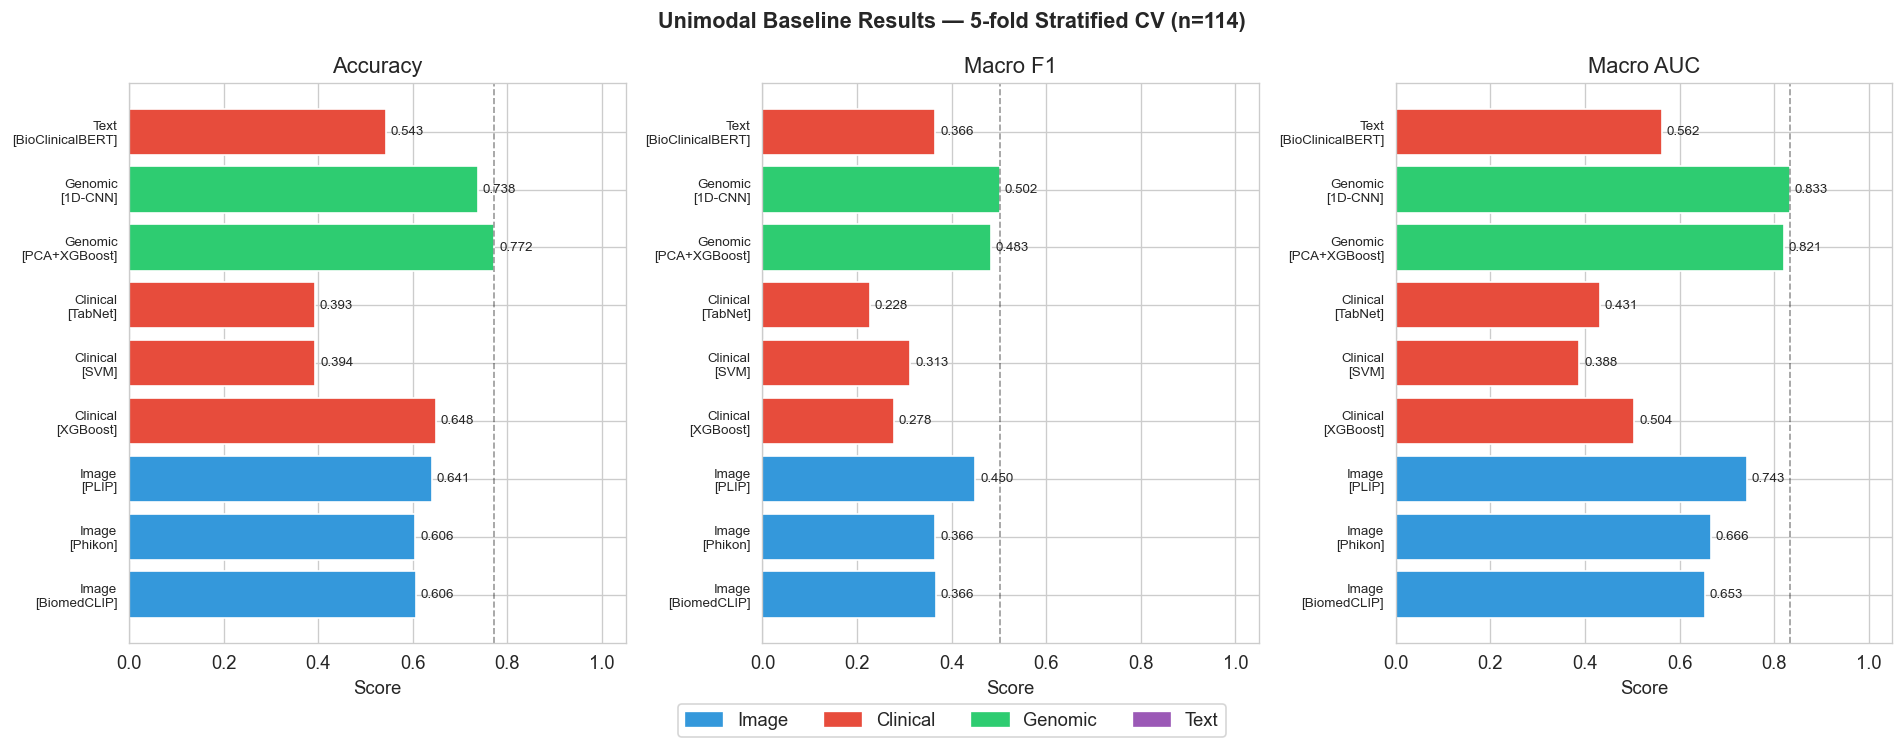

Saved: 09_unimodal_baselines.png
Phase 2 complete. Proceeding to Phase 3: Fusion Models.


In [16]:
methods = list(RESULTS.keys())
colors  = ['#3498db' if 'Image'    in m else
           '#e74c3c' if 'Clinical' in m else
           '#2ecc71' if 'Genomic'  in m else '#9b59b6'
           for m in methods]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Unimodal Baseline Results — 5-fold Stratified CV (n=114)',
             fontsize=13, fontweight='bold')

for ax, (metric, key) in zip(axes, [('Accuracy', '_acc'), ('Macro F1', '_f1'), ('Macro AUC', '_auc')]):
    vals = [RESULTS[m][key] for m in methods]
    bars = ax.barh(range(len(methods)), vals, color=colors, edgecolor='white')
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels([m.replace(' [', '\n[') for m in methods], fontsize=8)
    ax.set_xlim(0, 1.05); ax.set_title(metric); ax.set_xlabel('Score')
    ax.axvline(max(vals), color='black', linestyle='--', alpha=0.4, linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)

# Legend patches
import matplotlib.patches as mpatches
legend = [mpatches.Patch(color=c, label=l) for c, l in
          [('#3498db','Image'), ('#e74c3c','Clinical'), ('#2ecc71','Genomic'), ('#9b59b6','Text')]]
fig.legend(handles=legend, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '09_unimodal_baselines.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_unimodal_baselines.png')
print('Phase 2 complete. Proceeding to Phase 3: Fusion Models.')